# House Price Prediction

## Problem Statement

The objective of this project is to predict house prices based on different property features such as area, bedrooms, bathrooms, floors, year built, location, condition, and garage availability.

Since the target variable, Price, is a continuous numerical value, this is primarily a regression problem.

We will perform data preprocessing, exploratory data analysis, and apply different machine learning algorithms to predict house prices.

## Importing Required Libraries

We first import the Python libraries required for data loading, data analysis, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In this step, we load the house price dataset into a Pandas DataFrame.

A DataFrame allows us to store, inspect, clean, and analyze the dataset using Python.

In [2]:
df = pd.read_csv("Houseprice.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Checking the Dataset Size

In this step, we check the number of rows and columns in the dataset.

This helps us understand how much data is available for analysis and machine learning.

In [3]:
df.shape

(2000, 10)

## Understanding Dataset Information

In this step, we use the `info()` function to check the column names, data types, and whether any values are missing.

This helps us understand which columns are numerical and which columns are categorical before preprocessing.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


## Checking Missing Values

In this step, we check whether any values are missing in the dataset.

Missing values can affect machine learning models, so we need to identify them before building the models.

In [5]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


## Checking Duplicate Rows

In this step, we check whether the dataset contains duplicate records.

Duplicate records can affect the analysis and may give the machine learning model repeated information.

In [6]:
df.duplicated().sum()

np.int64(0)

## Statistical Summary of Numerical Features

In this step, we use `describe()` to understand the statistical properties of the numerical columns.

It shows values such as count, mean, minimum, maximum, and standard deviation.

In [8]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## Identifying Categorical Features

Some columns contain categories instead of numerical values.

In our dataset, `Location`, `Condition`, and `Garage` are categorical features. We identify them because they will need to be converted into numerical values before applying machine learning algorithms.

In [9]:
categorical_columns = df.select_dtypes(include="object").columns

categorical_columns

Index(['Location', 'Condition', 'Garage'], dtype='object')

## Checking Unique Values in Categorical Features

Before encoding the categorical features, we check the unique values present in each categorical column.

This helps us understand the different categories that need to be converted into numerical values.

In [10]:
for col in categorical_columns:
    print(f"{col}:")
    print(df[col].unique())
    print()

Location:
['Downtown' 'Suburban' 'Urban' 'Rural']

Condition:
['Excellent' 'Good' 'Fair' 'Poor']

Garage:
['No' 'Yes']



## Visualizing Categorical Features

In this step, we visualize the categorical features to understand how the different categories are distributed in the dataset.

This helps us identify whether some categories have significantly more observations than others.

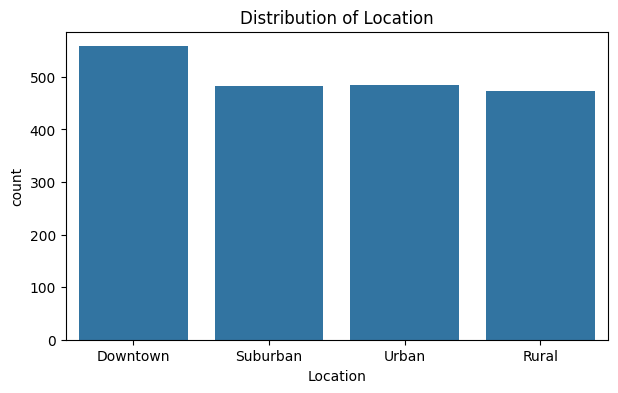

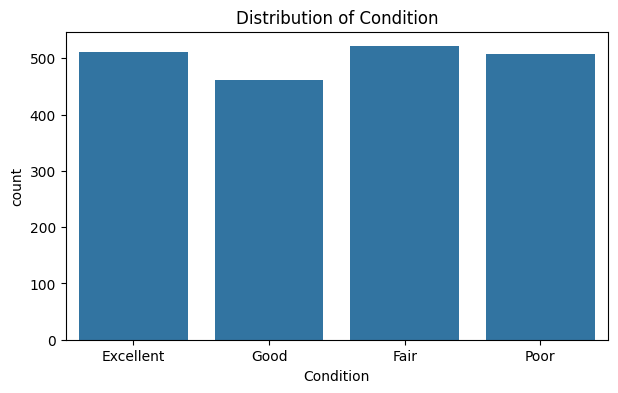

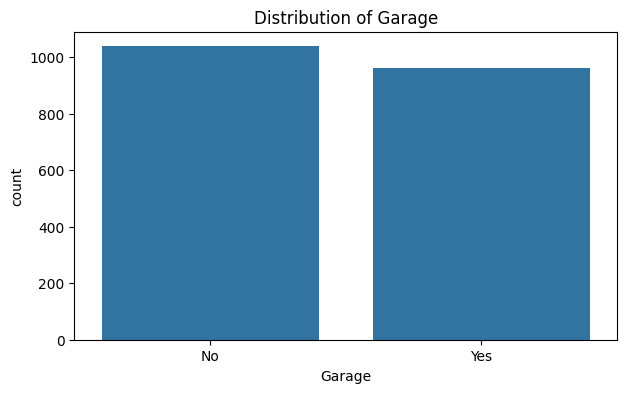

In [11]:
for col in categorical_columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=0)
    plt.show()

## Exploring the Target Variable — Price

Since `Price` is our target variable, we first examine its distribution.

This helps us understand how house prices are spread across the dataset and whether there are any unusually high or low values.

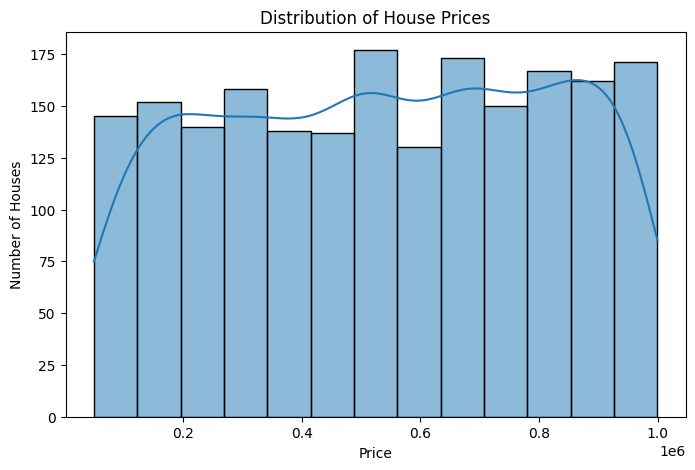

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

## Relationship Between Area and Price

Area is one of the important features that may influence house price.

In this step, we use a scatter plot to visualize the relationship between the house area and its price.

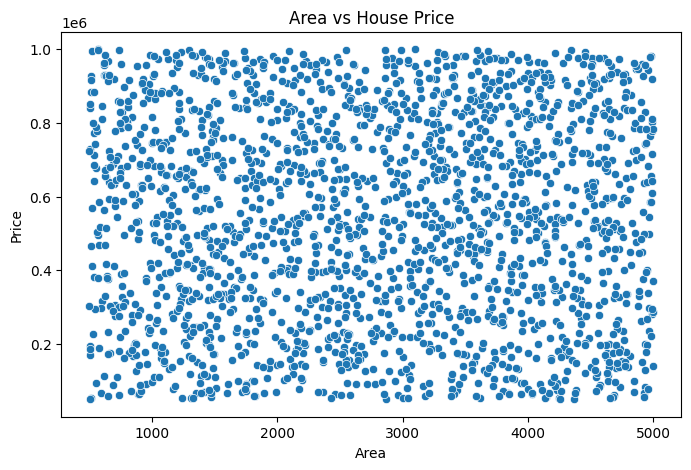

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Area", y="Price")
plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

## Relationship Between Bedrooms and Price

Bedrooms may also influence the price of a house.

In this step, we visualize the relationship between the number of bedrooms and house price.

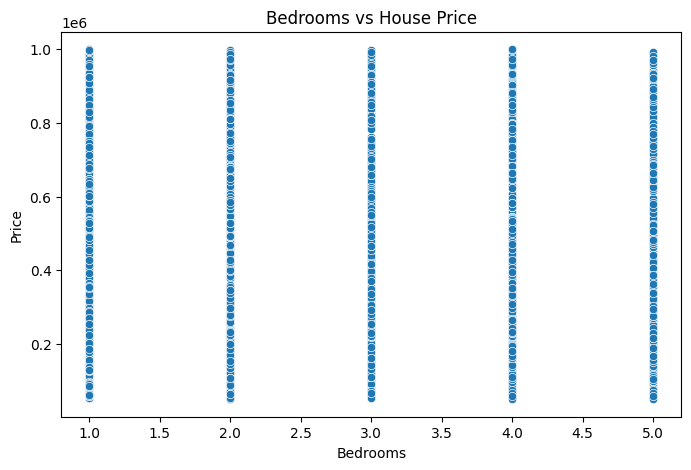

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Bedrooms", y="Price")
plt.title("Bedrooms vs House Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

## Relationship Between Bathrooms and Price

Bathrooms are another numerical feature that may influence house price.

In this step, we visualize the relationship between the number of bathrooms and house price.

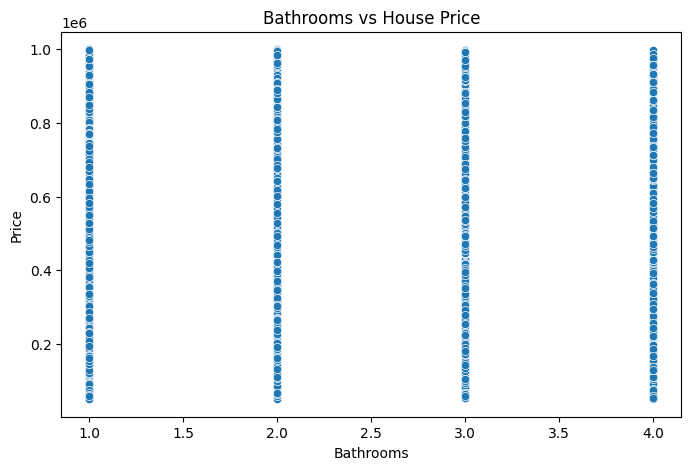

In [15]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Bathrooms", y="Price")
plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

## Relationship Between Floors and Price

Floors represent the number of floors in a house and may influence its price.

In this step, we visualize the relationship between the number of floors and house price.

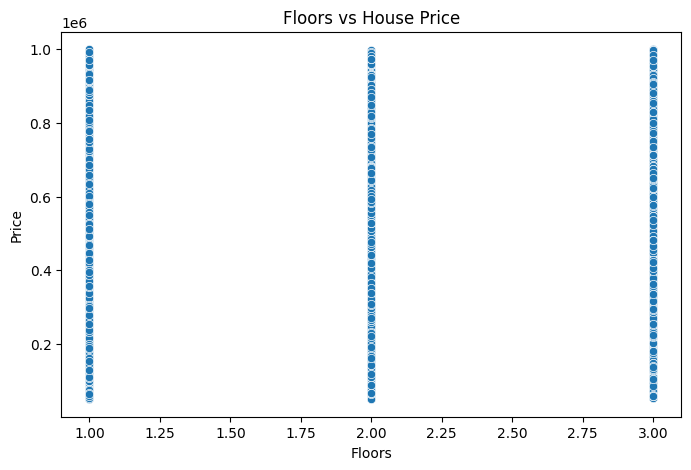

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Floors", y="Price")
plt.title("Floors vs House Price")
plt.xlabel("Floors")
plt.ylabel("Price")
plt.show()

## Relationship Between Year Built and Price

The year a house was built may have an effect on its price.

In this step, we visualize the relationship between the year the house was built and its price.

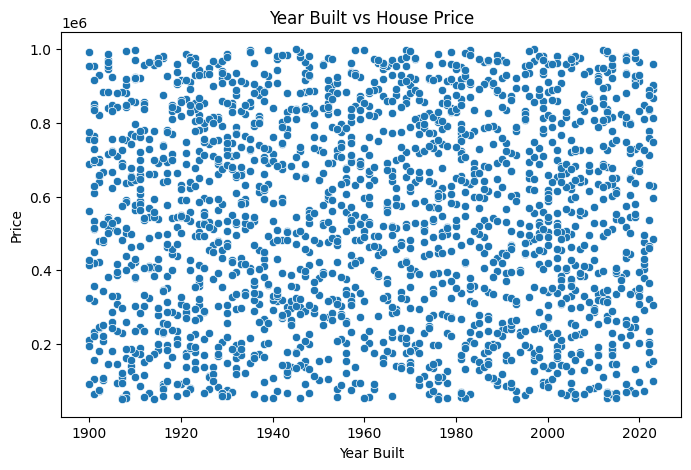

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="YearBuilt", y="Price")
plt.title("Year Built vs House Price")
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.show()

## Relationship Between Location and Price

Location can have an important effect on house prices because houses in different areas may have different price ranges.

In this step, we visualize the distribution of house prices across different locations.

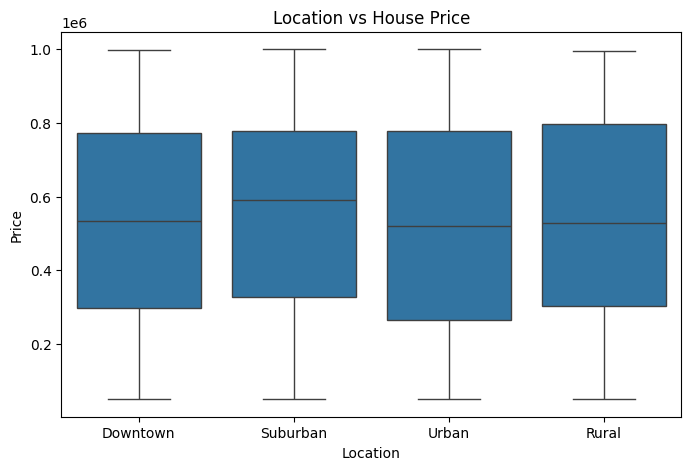

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Location", y="Price")
plt.title("Location vs House Price")
plt.xlabel("Location")
plt.ylabel("Price")
plt.show()

## Relationship Between Condition and Price

The condition of a house may affect its price.

In this step, we visualize the distribution of house prices across different house conditions.

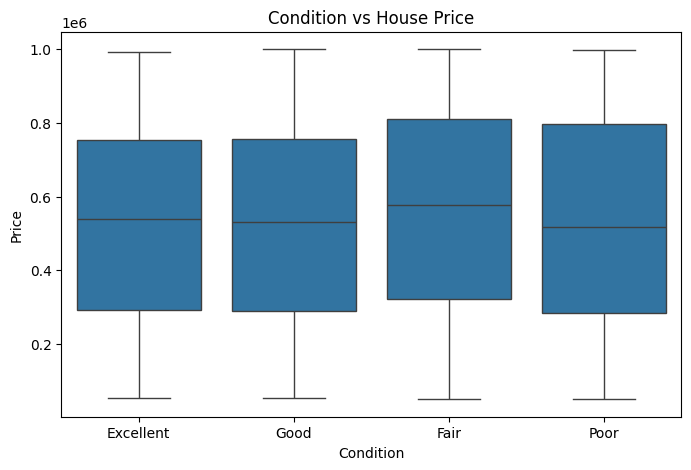

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Condition", y="Price")
plt.title("Condition vs House Price")
plt.xlabel("Condition")
plt.ylabel("Price")
plt.show()

## Relationship Between Garage Availability and Price

Garage availability may influence the price of a house.

In this step, we visualize the difference in house prices between properties with and without a garage.

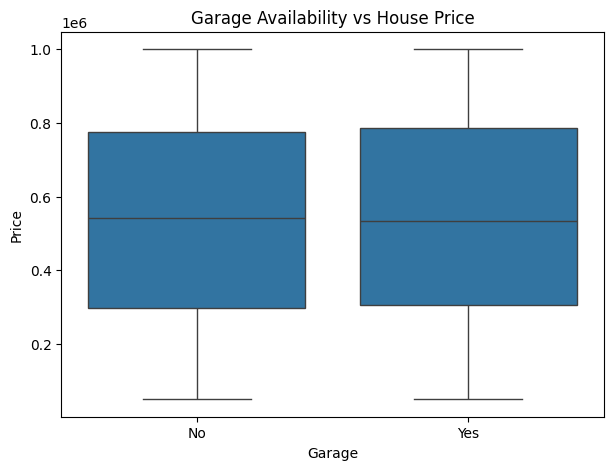

In [20]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Garage", y="Price")
plt.title("Garage Availability vs House Price")
plt.xlabel("Garage")
plt.ylabel("Price")
plt.show()

## Correlation Between Numerical Features

In this step, we analyze the correlation between the numerical features in the dataset.

Correlation helps us understand how strongly two numerical variables are related to each other. We are especially interested in how the features are related to `Price`.

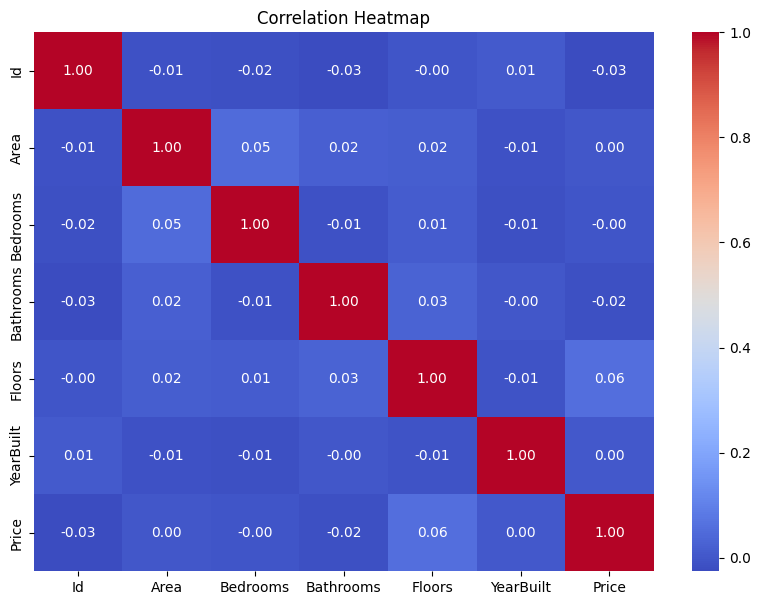

In [21]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Removing Unnecessary Columns

The `Id` column is only used to identify each house and does not contain useful information about the property.

Therefore, we remove it before training the machine learning models.

In [22]:
df = df.drop("Id", axis=1)

df.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## Separating Features and Target Variable

In this step, we separate the dataset into input features (`X`) and the target variable (`y`).

`X` contains the house characteristics that the model will use for prediction, while `y` contains the actual house price that we want to predict.

In [23]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage
0  1360         5          4       3       1970  Downtown  Excellent     No
1  4272         5          4       3       1958  Downtown  Excellent     No
2  3592         2          2       3       1938  Downtown       Good     No
3   966         4          2       2       1902  Suburban       Fair    Yes
4  4926         1          4       2       1975  Downtown       Fair    Yes

Target (y):
0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64


## Splitting the Dataset into Training and Testing Data

In this step, we divide the dataset into training data and testing data.

The training data is used to teach the machine learning model, while the testing data is used to evaluate how well the model performs on unseen data.

We use 80% of the data for training and 20% for testing.

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 8)
Testing data: (400, 8)


## Encoding Categorical Features

Machine learning models work with numerical values, but our dataset contains categorical features such as `Location`, `Condition`, and `Garage`.

In this step, we convert these categorical values into numerical values using one-hot encoding.

This allows the machine learning models to use the categorical information without treating the categories as ordered numbers.

In [25]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Training data after encoding:", X_train.shape)
print("Testing data after encoding:", X_test.shape)

X_train.head()

Training data after encoding: (1600, 12)
Testing data after encoding: (400, 12)


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
968,4483,4,4,3,1933,False,False,True,False,False,False,False
240,1062,3,3,1,1970,False,False,False,False,True,False,False
819,1422,3,4,1,1993,False,False,True,False,True,False,True
692,2658,2,3,1,1972,True,False,False,False,False,True,True
420,3286,2,4,1,1981,True,False,False,False,False,False,True


## Scaling the Numerical Features

Some numerical features have different ranges. For example, `Area` contains values in thousands, while `Bedrooms` contains small values.

In this step, we scale the features to a similar range so that algorithms such as KNN and SVR are not unfairly affected by larger numerical values.

We fit the scaler only on the training data and then apply the same transformation to the testing data.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (1600, 12)
Scaled testing data shape: (400, 12)


## Linear Regression Model

Linear Regression is a basic regression algorithm used to predict a continuous numerical value.

In our project, we use Linear Regression to predict house prices based on the available house features.

This model will serve as a baseline so that we can compare its performance with other regression algorithms.

In [27]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression predictions:")
print(y_pred_linear[:5])

Linear Regression predictions:
[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512]


## Evaluating the Linear Regression Model

After making predictions, we need to measure how accurately the model predicts house prices.

We use three evaluation metrics:
- MAE (Mean Absolute Error)
- MSE (Mean Squared Error)
- R² Score (R-squared)

These metrics help us understand the prediction error and how well the model explains the variation in house prices.

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("R² Score:", r2_linear)

Linear Regression Performance
MAE: 243241.97758826384
MSE: 78321466146.0328
R² Score: -0.006717808430749761


## Testing the Model Without Bathrooms

In this step, we temporarily remove the `Bathrooms` feature and train Linear Regression again.

We are doing this to check whether removing a feature with almost zero correlation with Price changes the model performance.

We will compare the new R² score with the previous R² score.

In [29]:
# Create copies so the original data is not changed
X_train_no_bath = X_train.drop("Bathrooms", axis=1)
X_test_no_bath = X_test.drop("Bathrooms", axis=1)

# Scale the updated features
scaler_no_bath = StandardScaler()

X_train_no_bath_scaled = scaler_no_bath.fit_transform(X_train_no_bath)
X_test_no_bath_scaled = scaler_no_bath.transform(X_test_no_bath)

# Train Linear Regression
linear_no_bath = LinearRegression()
linear_no_bath.fit(X_train_no_bath_scaled, y_train)

# Predictions
y_pred_no_bath = linear_no_bath.predict(X_test_no_bath_scaled)

# Evaluate
r2_no_bath = r2_score(y_test, y_pred_no_bath)

print("R² with Bathrooms:", r2_linear)
print("R² without Bathrooms:", r2_no_bath)

R² with Bathrooms: -0.006717808430749761
R² without Bathrooms: 0.0005056901910037714


In [34]:
# Use the dataset with only Bathrooms removed
X_train_lr = X_train.drop("Bathrooms", axis=1)
X_test_lr = X_test.drop("Bathrooms", axis=1)

# Scale the features
scaler_lr = StandardScaler()

X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

# Train Linear Regression
linear_model_final = LinearRegression()
linear_model_final.fit(X_train_lr_scaled, y_train)

# Predictions
y_pred_linear_final = linear_model_final.predict(X_test_lr_scaled)

# Evaluation
mae_linear_final = mean_absolute_error(y_test, y_pred_linear_final)
mse_linear_final = mean_squared_error(y_test, y_pred_linear_final)
r2_linear_final = r2_score(y_test, y_pred_linear_final)

print("Final Linear Regression Performance")
print("MAE:", mae_linear_final)
print("MSE:", mse_linear_final)
print("R² Score:", r2_linear_final)

Final Linear Regression Performance
MAE: 241960.18772664896
MSE: 77759486415.44527
R² Score: 0.0005056901910037714


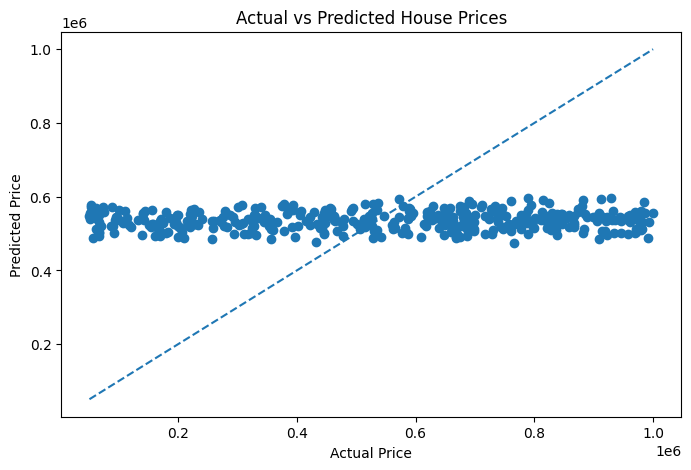

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_linear_final)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

## K-Nearest Neighbors (KNN) Regression

KNN Regression predicts the price of a house by looking at the prices of similar houses in the training data.

Since KNN depends on the distance between data points, we use the scaled features prepared during preprocessing.

In this step, we train a KNN Regressor and evaluate its performance using MAE, MSE, and R² Score.

In [41]:
from sklearn.neighbors import KNeighborsRegressor

# Remove Bathrooms
X_train_knn = X_train.drop("Bathrooms", axis=1)
X_test_knn = X_test.drop("Bathrooms", axis=1)

# Scale the features
scaler_knn = StandardScaler()

X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

# Train KNN
knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_knn_scaled, y_train)

# Predictions
y_pred_knn = knn_model.predict(X_test_knn_scaled)

# Evaluation
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regression Performance")
print("MAE:", mae_knn)
print("MSE:", mse_knn)
print("R² Score:", r2_knn)

KNN Regression Performance
MAE: 261212.7725
MSE: 97196174147.8415
R² Score: -0.24932696284727052


## Decision Tree Regression

Decision Tree Regression predicts house prices by making a series of decisions based on the input features.

The model divides the data into smaller groups based on feature values and predicts a price for each group.

In this step, we train a Decision Tree Regressor and evaluate its performance using MAE, MSE, and R² Score.

In [42]:
from sklearn.tree import DecisionTreeRegressor

# Remove Bathrooms
X_train_tree = X_train.drop("Bathrooms", axis=1)
X_test_tree = X_test.drop("Bathrooms", axis=1)

# Train Decision Tree
decision_tree_model = DecisionTreeRegressor(random_state=42)

decision_tree_model.fit(X_train_tree, y_train)

# Predictions
y_pred_tree = decision_tree_model.predict(X_test_tree)

# Evaluation
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Performance")
print("MAE:", mae_tree)
print("MSE:", mse_tree)
print("R² Score:", r2_tree)

Decision Tree Regression Performance
MAE: 338035.975
MSE: 170148170462.18
R² Score: -1.187027410299109


## Support Vector Regression (SVR)

Support Vector Regression is a regression algorithm that tries to find a suitable function for predicting continuous values.

In this step, we use SVR to predict house prices from the scaled house features.

Since SVR is sensitive to the scale of the features, we use the scaled training and testing data.

We evaluate the model using MAE, MSE, and R² Score.

In [43]:
from sklearn.svm import SVR

# Remove Bathrooms
X_train_svr = X_train.drop("Bathrooms", axis=1)
X_test_svr = X_test.drop("Bathrooms", axis=1)

# Scale the features
scaler_svr = StandardScaler()

X_train_svr_scaled = scaler_svr.fit_transform(X_train_svr)
X_test_svr_scaled = scaler_svr.transform(X_test_svr)

# Train SVR
svr_model = SVR()

svr_model.fit(X_train_svr_scaled, y_train)

# Predictions
y_pred_svr = svr_model.predict(X_test_svr_scaled)

# Evaluation
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Performance")
print("MAE:", mae_svr)
print("MSE:", mse_svr)
print("R² Score:", r2_svr)

SVR Performance
MAE: 242647.20284691214
MSE: 77902377181.72804
R² Score: -0.0013309797049472216


## Random Forest Regression

Random Forest Regression combines multiple Decision Trees and uses their combined predictions to predict the house price.

Using multiple trees can help the model learn more complex relationships in the data.

In this step, we train a Random Forest Regressor and evaluate its performance using MAE, MSE, and R² Score.

In [38]:
from sklearn.ensemble import RandomForestRegressor

# Remove Bathrooms
X_train_rf = X_train.drop("Bathrooms", axis=1)
X_test_rf = X_test.drop("Bathrooms", axis=1)

# Train Random Forest
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_rf, y_train)

# Predictions
y_pred_rf = random_forest_model.predict(X_test_rf)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Performance")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("R² Score:", r2_rf)

Random Forest Regression Performance
MAE: 252518.030125
MSE: 85298979559.80693
R² Score: -0.09640442128237403


## Bagging Regression Without Bathrooms

In this step, we remove the `Bathrooms` feature and train a Bagging Regressor.

Bagging combines predictions from multiple models to improve the overall prediction.

We use the same feature set as the other regression models for a fair comparison.

In [44]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Remove Bathrooms
X_train_bag = X_train.drop("Bathrooms", axis=1)
X_test_bag = X_test.drop("Bathrooms", axis=1)

# Train Bagging Regressor
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train_bag, y_train)

# Predictions
y_pred_bag = bagging_model.predict(X_test_bag)

# Evaluation
mae_bag = mean_absolute_error(y_test, y_pred_bag)
mse_bag = mean_squared_error(y_test, y_pred_bag)
r2_bag = r2_score(y_test, y_pred_bag)

print("Bagging Regression Performance")
print("MAE:", mae_bag)
print("MSE:", mse_bag)
print("R² Score:", r2_bag)

Bagging Regression Performance
MAE: 252092.4226
MSE: 85951964199.57639
R² Score: -0.10479766642747834


## Boosting Regression Without Bathrooms

In this step, we remove the `Bathrooms` feature and train a Boosting Regressor.

Boosting builds multiple models sequentially, where each new model tries to improve the errors made by the previous models.

We use the same feature set as the other regression models for a fair comparison.

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

# Remove Bathrooms
X_train_boost = X_train.drop("Bathrooms", axis=1)
X_test_boost = X_test.drop("Bathrooms", axis=1)

# Train Boosting Regressor
boosting_model = GradientBoostingRegressor(random_state=42)

boosting_model.fit(X_train_boost, y_train)

# Predictions
y_pred_boost = boosting_model.predict(X_test_boost)

# Evaluation
mae_boost = mean_absolute_error(y_test, y_pred_boost)
mse_boost = mean_squared_error(y_test, y_pred_boost)
r2_boost = r2_score(y_test, y_pred_boost)

print("Boosting Regression Performance")
print("MAE:", mae_boost)
print("MSE:", mse_boost)
print("R² Score:", r2_boost)

Boosting Regression Performance
MAE: 247079.85801459328
MSE: 81990828323.3286
R² Score: -0.05388255688653465


## Creating a Classification Target for Logistic Regression

Our original target variable, `Price`, is a continuous numerical value, so it is suitable for regression.

Logistic Regression is a classification algorithm, so it cannot directly predict the exact house price.

Therefore, we create a new target called `Price_Category`.

Houses with a price less than or equal to the median price will be classified as `Low`, while houses above the median price will be classified as `High`.

This allows us to demonstrate classification while keeping the original problem focused on house prices.

In [46]:
# Find the median house price
median_price = df["Price"].median()

# Create price categories
df["Price_Category"] = np.where(
    df["Price"] <= median_price,
    "Low",
    "High"
)

print("Median Price:", median_price)
print("\nPrice Category Distribution:")
print(df["Price_Category"].value_counts())

Median Price: 539254.0

Price Category Distribution:
Price_Category
Low     1000
High    1000
Name: count, dtype: int64


## Preparing Data for Logistic Regression

In this step, we separate the input features from the new classification target.

The input features contain the house characteristics, while `Price_Category` is the target we want to predict.

We also remove the original `Price` column because it was used to create the category and should not be given to the model as an input feature.

In [47]:
# Separate features and classification target
X_class = df.drop(["Price", "Price_Category"], axis=1)
y_class = df["Price_Category"]

print("Features:")
print(X_class.head())

print("\nTarget:")
print(y_class.head())

Features:
   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage
0  1360         5          4       3       1970  Downtown  Excellent     No
1  4272         5          4       3       1958  Downtown  Excellent     No
2  3592         2          2       3       1938  Downtown       Good     No
3   966         4          2       2       1902  Suburban       Fair    Yes
4  4926         1          4       2       1975  Downtown       Fair    Yes

Target:
0     Low
1     Low
2     Low
3     Low
4    High
Name: Price_Category, dtype: object


## Splitting the Classification Dataset

In this step, we divide the classification dataset into training and testing data.

The training data is used to teach the Logistic Regression model, while the testing data is used to check how well it classifies unseen houses.

We use 80% of the data for training and 20% for testing.

In [48]:
from sklearn.model_selection import train_test_split

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_class_train.shape)
print("Testing data:", X_class_test.shape)

Training data: (1600, 8)
Testing data: (400, 8)


## Encoding Categorical Features for Logistic Regression

Logistic Regression works with numerical values, but our dataset contains categorical features such as `Location`, `Condition`, and `Garage`.

In this step, we convert these categorical features into numerical values using one-hot encoding.

We also make sure that the training and testing datasets have the same columns after encoding.

In [49]:
# One-hot encode categorical features
X_class_train = pd.get_dummies(X_class_train, drop_first=True)
X_class_test = pd.get_dummies(X_class_test, drop_first=True)

# Make sure both datasets have the same columns
X_class_test = X_class_test.reindex(
    columns=X_class_train.columns,
    fill_value=0
)

print("Training data after encoding:", X_class_train.shape)
print("Testing data after encoding:", X_class_test.shape)

X_class_train.head()

Training data after encoding: (1600, 12)
Testing data after encoding: (400, 12)


,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
968,4483,4,4,3,1933,False,False,True,False,False,False,False
240,1062,3,3,1,1970,False,False,False,False,True,False,False
819,1422,3,4,1,1993,False,False,True,False,True,False,True
692,2658,2,3,1,1972,True,False,False,False,False,True,True
420,3286,2,4,1,1981,True,False,False,False,False,False,True


## Scaling Features for Logistic Regression

In this step, we scale the input features so that numerical features with different ranges are brought to a similar scale.

This helps Logistic Regression work more effectively when features have different numerical ranges.

We fit the scaler only on the training data and apply the same transformation to the testing data.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler_class = StandardScaler()

X_class_train_scaled = scaler_class.fit_transform(X_class_train)
X_class_test_scaled = scaler_class.transform(X_class_test)

print("Scaled training data shape:", X_class_train_scaled.shape)
print("Scaled testing data shape:", X_class_test_scaled.shape)

Scaled training data shape: (1600, 12)
Scaled testing data shape: (400, 12)


## Logistic Regression Model

Logistic Regression is a classification algorithm used to predict categories.

In our project, the model predicts whether a house belongs to the `Low` or `High` price category based on its features.

We train the model using the scaled training data and then make predictions on the testing data.

In [51]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_class_train_scaled, y_class_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_class_test_scaled)

print("Logistic Regression Predictions:")
print(y_pred_logistic[:10])

Logistic Regression Predictions:
['High' 'High' 'Low' 'Low' 'Low' 'Low' 'Low' 'High' 'High' 'High']


## Evaluating Logistic Regression

In this step, we evaluate the classification performance of the Logistic Regression model.

We use:
- Accuracy to measure the overall percentage of correct predictions.
- Confusion Matrix to see correct and incorrect predictions for each category.
- Classification Report to calculate precision, recall, and F1-score.

These metrics help us understand how well the model classifies houses as Low or High price.

In [52]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy_logistic = accuracy_score(y_class_test, y_pred_logistic)

# Confusion matrix
cm_logistic = confusion_matrix(y_class_test, y_pred_logistic)

# Classification report
report_logistic = classification_report(y_class_test, y_pred_logistic)

print("Logistic Regression Accuracy:", accuracy_logistic)

print("\nConfusion Matrix:")
print(cm_logistic)

print("\nClassification Report:")
print(report_logistic)

Logistic Regression Accuracy: 0.5

Confusion Matrix:
[[ 97 113]
 [ 87 103]]

Classification Report:
              precision    recall  f1-score   support

        High       0.53      0.46      0.49       210
         Low       0.48      0.54      0.51       190

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.50      0.50      0.50       400



In [54]:
# Create final regression comparison table

regression_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae_linear_final,
        "MSE": mse_linear_final,
        "R2 Score": r2_linear_final
    },
    {
        "Model": "KNN Regression",
        "MAE": mae_knn,
        "MSE": mse_knn,
        "R2 Score": r2_knn
    },
    {
        "Model": "Decision Tree",
        "MAE": mae_tree,
        "MSE": mse_tree,
        "R2 Score": r2_tree
    },
    {
        "Model": "SVR",
        "MAE": mae_svr,
        "MSE": mse_svr,
        "R2 Score": r2_svr
    },
    {
        "Model": "Random Forest",
        "MAE": mae_rf,
        "MSE": mse_rf,
        "R2 Score": r2_rf
    },
    {
        "Model": "Bagging",
        "MAE": mae_bag,
        "MSE": mse_bag,
        "R2 Score": r2_bag
    },
    {
        "Model": "Boosting",
        "MAE": mae_boost,
        "MSE": mse_boost,
        "R2 Score": r2_boost
    }
])

regression_results

,Model,MAE,MSE,R2 Score
0,Linear Regression,241960.187727,7.775949e+10,0.000506
1,KNN Regression,261212.772500,9.719617e+10,-0.249327
2,Decision Tree,338035.975000,1.701482e+11,-1.187027
3,SVR,242647.202847,7.790238e+10,-0.001331
4,Random Forest,252518.030125,8.529898e+10,-0.096404
5,Bagging,252092.422600,8.595196e+10,-0.104798
6,Boosting,247079.858015,8.199083e+10,-0.053883


# Conclusion

The objective of this project was to predict house prices using different machine learning algorithms.

We first performed data preprocessing and exploratory data analysis. We checked for missing values and duplicate records, analyzed numerical and categorical features, and visualized their relationships with house prices.

We then prepared the data using categorical encoding, feature scaling, and train-test splitting. We applied several regression algorithms, including Linear Regression, KNN, Decision Tree, SVR, Random Forest, Bagging, and Boosting.

The regression models showed low predictive performance, with R² scores close to or below zero. The actual-versus-predicted plot also showed that the predicted prices were mostly concentrated around the average price.

For classification, we converted house prices into two categories: Low and High. Logistic Regression achieved 50% accuracy on the test data.

The low model performance indicates that the available features in this dataset have weak relationships with house prices. Therefore, the models have limited information from which to learn accurate price patterns.

Overall, this project helped demonstrate the complete machine learning workflow, including data preprocessing, exploratory data analysis, feature preparation, model training, evaluation, and comparison of different machine learning algorithms.
